# EDA do Dataset 3W (Petrobras)

Este notebook foi preparado para analisar os dados que alimentam o pipeline atual do projeto.

Objetivos:
- Entender volume e cobertura dos arquivos `.parquet`
- Inspecionar distribuição de classes/eventos
- Avaliar qualidade dos dados (nulos, duplicados, faixas)
- Visualizar séries temporais e correlações de sensores

> Observacao: para ler `.parquet`, use `pyarrow` ou `fastparquet` instalado no ambiente.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

print('Versao pandas:', pd.__version__)

Versao pandas: 2.3.3


In [2]:
# Resolucao de caminho semelhante ao script de ingestao do projeto
CANDIDATOS_DATASET = [
    Path('../3W/dataset'),
    Path('3W/dataset'),
    Path('/app/3W/dataset'),
    Path('/app/data/3W/dataset'),
]

dataset_dir = next((p.resolve() for p in CANDIDATOS_DATASET if p.exists()), None)
if dataset_dir is None:
    raise FileNotFoundError('Nao encontrei o dataset 3W. Ajuste a lista CANDIDATOS_DATASET.')

parquet_files = sorted(dataset_dir.rglob('*.parquet'))
print('Dataset dir:', dataset_dir)
print('Total de arquivos parquet:', len(parquet_files))

if len(parquet_files) == 0:
    raise RuntimeError('Nenhum parquet encontrado no diretorio selecionado.')

Dataset dir: /home/piratello/Desktop/AI Projects/Petrobras3w/3W/dataset
Total de arquivos parquet: 2228


In [3]:
# Metadados dos arquivos para entender cobertura por classe (pastas 0..9)
meta_files = pd.DataFrame({
    'file_path': [str(p) for p in parquet_files],
    'folder_label': [p.parent.name for p in parquet_files],
    'file_name': [p.name for p in parquet_files],
})

display(meta_files.head())
display(meta_files['folder_label'].value_counts().sort_index().to_frame('qtd_arquivos'))

,file_path,folder_label,file_name
0,/home/piratello/Desktop/AI Projects/Petrobras3...,0,WELL-00001_20170201010207.parquet
1,/home/piratello/Desktop/AI Projects/Petrobras3...,0,WELL-00001_20170201060114.parquet
2,/home/piratello/Desktop/AI Projects/Petrobras3...,0,WELL-00001_20170201110124.parquet
3,/home/piratello/Desktop/AI Projects/Petrobras3...,0,WELL-00001_20170201160311.parquet
4,/home/piratello/Desktop/AI Projects/Petrobras3...,0,WELL-00001_20170201210228.parquet


,qtd_arquivos
folder_label,
0,594
1,128
2,38
3,106
4,343
5,450
6,221
7,46
8,95


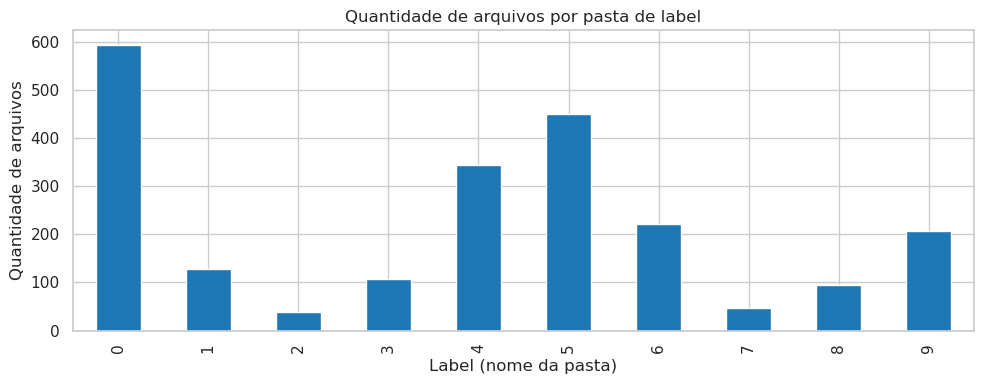

In [4]:
plt.figure(figsize=(10, 4))
ax = meta_files['folder_label'].value_counts().sort_index().plot(kind='bar', color='#1f77b4')
ax.set_title('Quantidade de arquivos por pasta de label')
ax.set_xlabel('Label (nome da pasta)')
ax.set_ylabel('Quantidade de arquivos')
plt.tight_layout()
plt.show()

In [5]:
# Leitura amostral para EDA rapido (ajuste os limites conforme sua maquina)
MAX_FILES = 120
MAX_ROWS_PER_FILE = 2500

def normalizar_dataframe(df: pd.DataFrame, fonte: Path) -> pd.DataFrame:
    if 'well' not in df.columns:
        df['well'] = fonte.stem
    if 'timestamp' not in df.columns:
        df['timestamp'] = df.index.astype(str)
    if 'evento' not in df.columns:
        if 'class' in df.columns:
            df['evento'] = df['class'].astype(str)
        elif 'state' in df.columns:
            df['evento'] = df['state'].astype(str)
        else:
            df['evento'] = 'normal'
    return df

amostra = []
for p in parquet_files[:MAX_FILES]:
    df = pd.read_parquet(p)
    if MAX_ROWS_PER_FILE and MAX_ROWS_PER_FILE > 0:
        df = df.head(MAX_ROWS_PER_FILE)
    if df.empty:
        continue
    df = normalizar_dataframe(df, p)
    df['source_file'] = p.name
    df['source_folder_label'] = p.parent.name
    amostra.append(df)

eda_df = pd.concat(amostra, ignore_index=False).reset_index(drop=True)
eda_df['timestamp'] = pd.to_datetime(eda_df['timestamp'], errors='coerce')

print('Shape da amostra:', eda_df.shape)
print('Arquivos usados:', min(len(parquet_files), MAX_FILES))
display(eda_df.head())

Shape da amostra: (300000, 34)
Arquivos usados: 120


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-ANULAR,P-JUS-BS,P-JUS-CKGL,P-JUS-CKP,P-MON-CKGL,P-MON-CKP,P-MON-SDV-P,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,well,timestamp,evento,source_file,source_folder_label
0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,NaN,1563422.0,NaN,NaN,1627884.0,NaN,0.0,NaN,10074540.0,NaN,0.0,84.64463,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,2017-02-01 01:02:07,<NA>,WELL-00001_20170201010207.parquet,0
1,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,NaN,1563422.0,NaN,NaN,1633397.0,NaN,0.0,NaN,10074540.0,NaN,0.0,84.63828,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,2017-02-01 01:02:08,<NA>,WELL-00001_20170201010207.parquet,0
2,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,NaN,1563422.0,NaN,NaN,1638909.0,NaN,0.0,NaN,10074540.0,NaN,0.0,84.63194,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,2017-02-01 01:02:09,<NA>,WELL-00001_20170201010207.parquet,0
3,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,NaN,1563422.0,NaN,NaN,1644422.0,NaN,0.0,NaN,10074540.0,NaN,0.0,84.62558,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,2017-02-01 01:02:10,<NA>,WELL-00001_20170201010207.parquet,0
4,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,NaN,1563423.0,NaN,NaN,1649934.0,NaN,0.0,NaN,10074540.0,NaN,0.0,84.61923,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,2017-02-01 01:02:11,<NA>,WELL-00001_20170201010207.parquet,0


In [6]:
print('Tipos de dados:')
display(eda_df.dtypes.to_frame('dtype').T)

print('\nNulos por coluna (top 20):')
display(eda_df.isna().sum().sort_values(ascending=False).head(20).to_frame('nulos'))

print('\nDuplicados exatos:', eda_df.duplicated().sum())

if 'evento' in eda_df.columns:
    display(eda_df['evento'].value_counts(dropna=False).to_frame('qtd_registros'))

if 'class' in eda_df.columns:
    display(eda_df['class'].value_counts(dropna=False).sort_index().to_frame('qtd_registros_class'))

Tipos de dados:


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-ANULAR,P-JUS-BS,P-JUS-CKGL,P-JUS-CKP,P-MON-CKGL,P-MON-CKP,P-MON-SDV-P,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,well,timestamp,evento,source_file,source_folder_label
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,Int16,Int16,object,datetime64[ns],object,object,object



Nulos por coluna (top 20):


,nulos
ABER-CKGL,300000
ABER-CKP,300000
P-JUS-CKP,300000
P-MON-CKGL,300000
P-MON-SDV-P,300000
P-JUS-BS,300000
class,300000
T-MON-CKP,300000
QBS,300000
PT-P,300000



Duplicados exatos: 0


,qtd_registros
evento,
<NA>,300000


,qtd_registros_class
class,
<NA>,300000


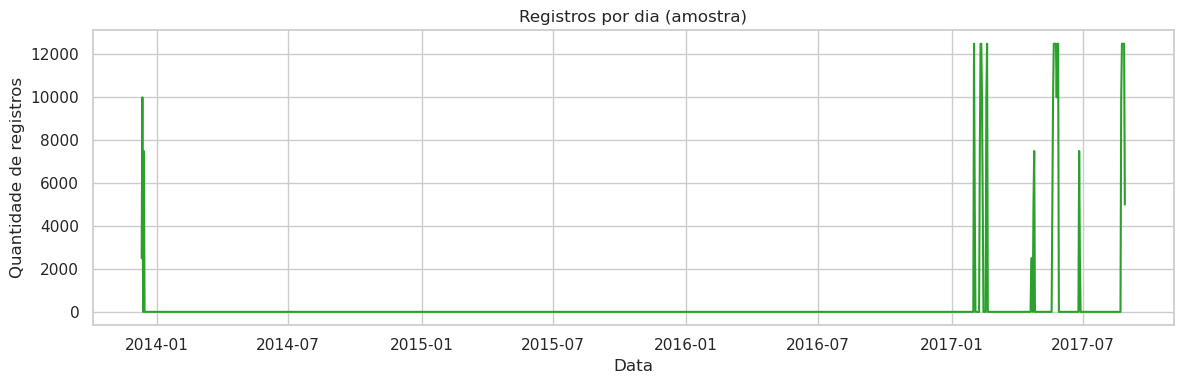

In [7]:
# Distribuicao temporal da amostra
if eda_df['timestamp'].notna().any():
    ts = eda_df.set_index('timestamp').sort_index()
    daily = ts.resample('D').size()
    plt.figure(figsize=(12, 4))
    plt.plot(daily.index, daily.values, color='#2ca02c')
    plt.title('Registros por dia (amostra)')
    plt.xlabel('Data')
    plt.ylabel('Quantidade de registros')
    plt.tight_layout()
    plt.show()
else:
    print('Sem timestamps validos para analise temporal.')

In [8]:
# Selecao automatica de sensores numericos para estatisticas e correlacao
nao_sensores = {'well', 'timestamp', 'evento', 'class', 'state', 'source_file', 'source_folder_label'}
sensor_cols = [c for c in eda_df.columns if c not in nao_sensores and pd.api.types.is_numeric_dtype(eda_df[c])]

print('Quantidade de sensores numericos:', len(sensor_cols))
print('Exemplo de sensores:', sensor_cols[:10])

if sensor_cols:
    display(eda_df[sensor_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)
else:
    print('Nenhum sensor numerico encontrado na amostra.')

Quantidade de sensores numericos: 27
Exemplo de sensores: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2']


,count,mean,std,min,1%,5%,50%,95%,99%,max
ABER-CKGL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ABER-CKP,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESTADO-DHSV,232500.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ESTADO-M1,232500.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ESTADO-M2,232500.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ESTADO-PXO,232500.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ESTADO-SDV-GL,232500.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ESTADO-SDV-P,232500.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ESTADO-W1,232500.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ESTADO-W2,232500.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


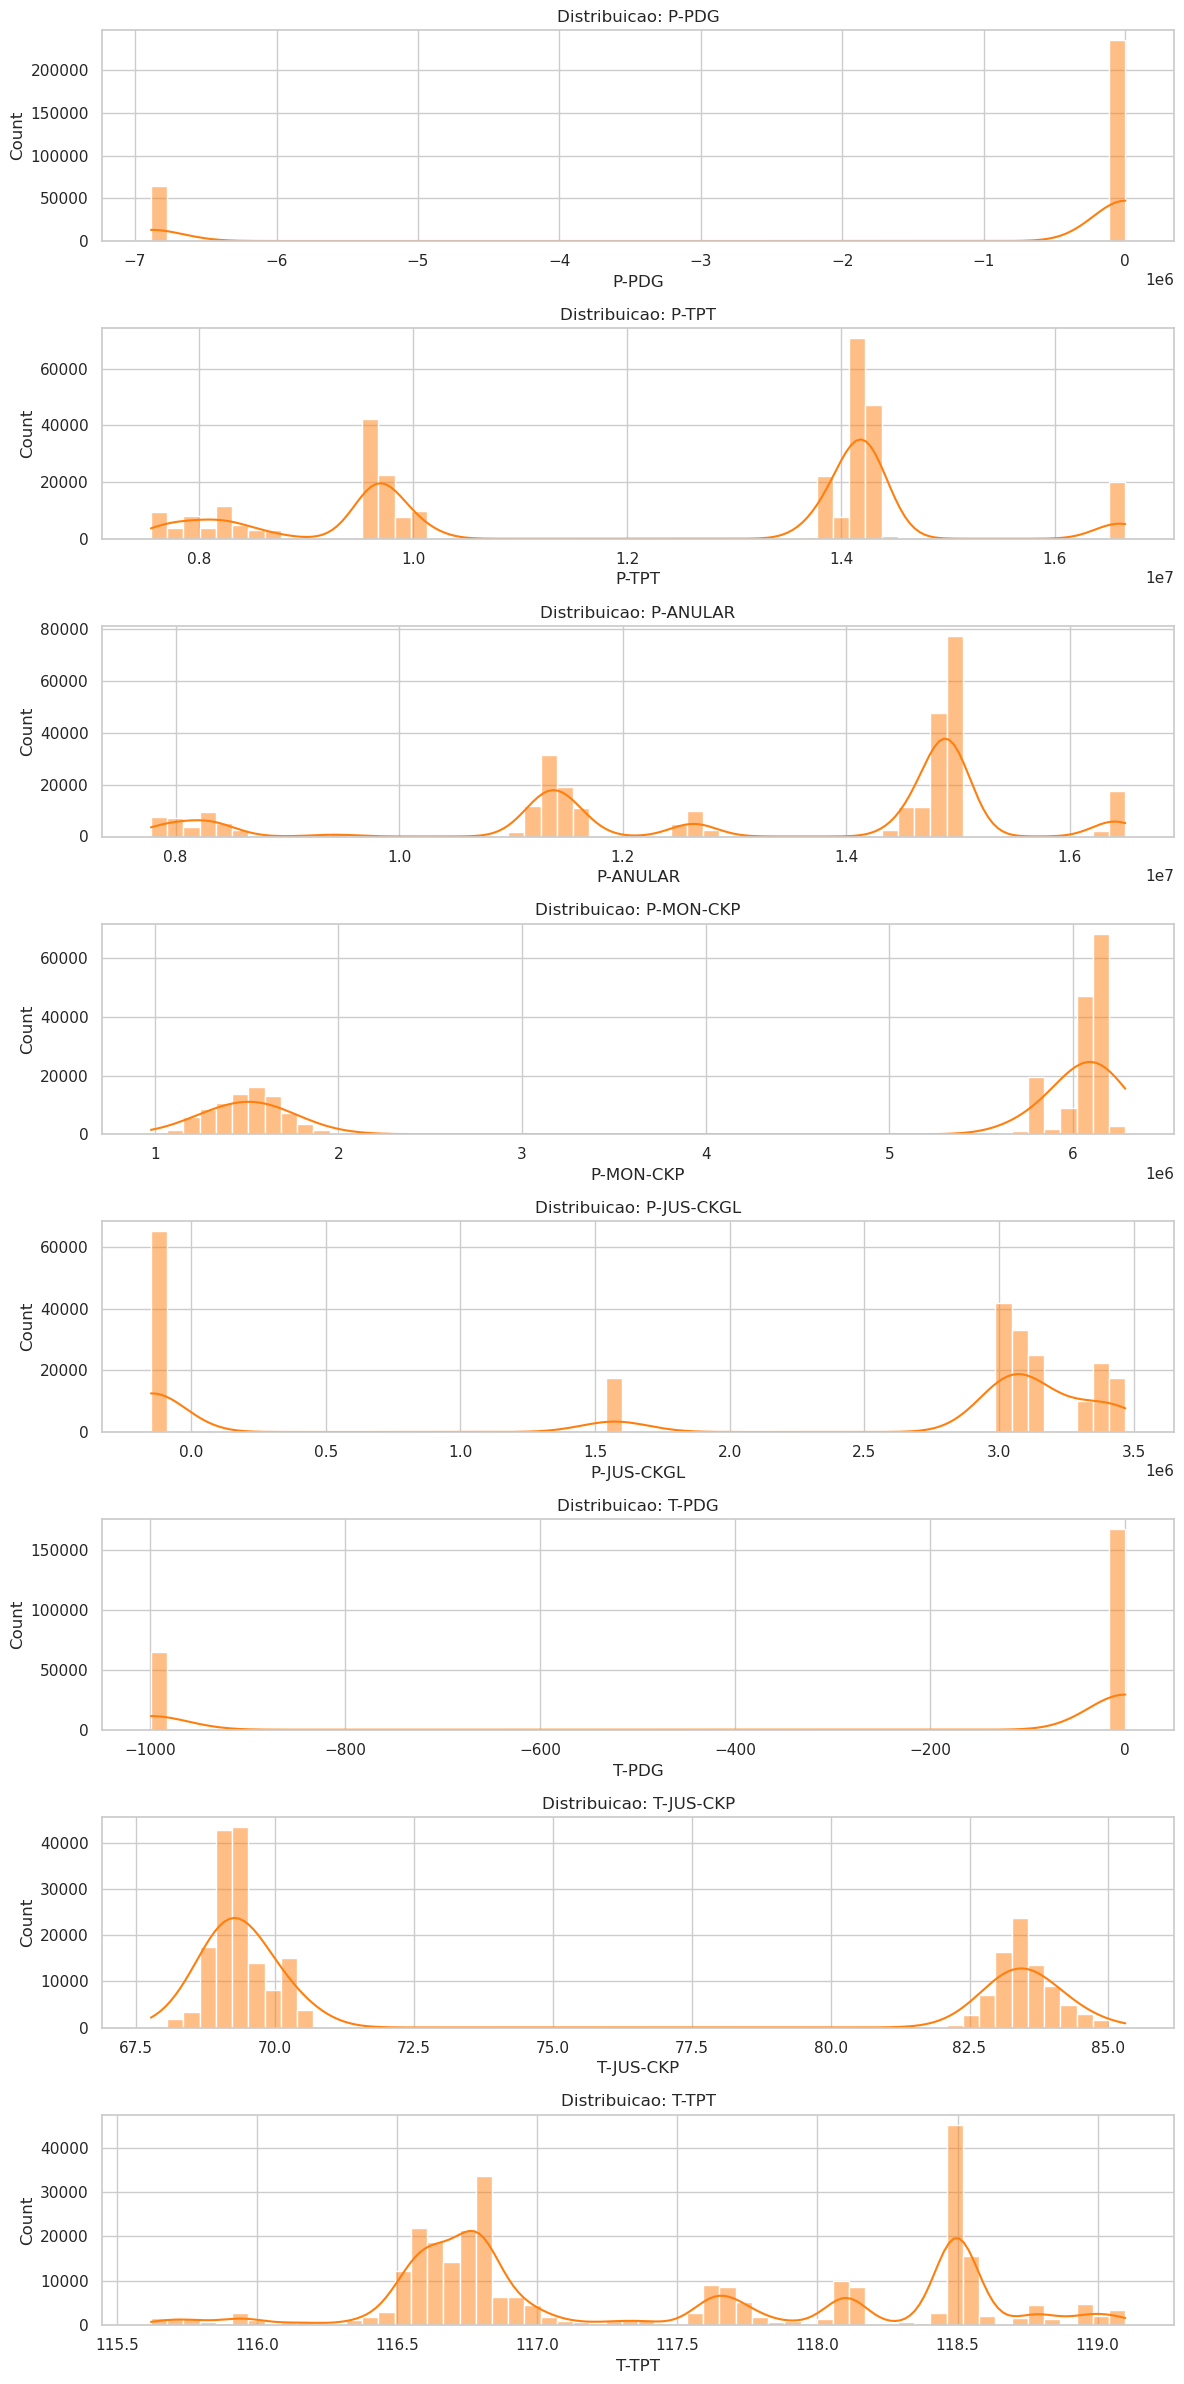

In [9]:
if sensor_cols:
    top_var = eda_df[sensor_cols].var(numeric_only=True).sort_values(ascending=False).head(8).index.tolist()
    n = len(top_var)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, max(3 * n, 6)))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, top_var):
        sns.histplot(eda_df[col].dropna(), bins=60, kde=True, ax=ax, color='#ff7f0e')
        ax.set_title(f'Distribuicao: {col}')
    plt.tight_layout()
    plt.show()
else:
    print('Sem sensores para histogramas.')

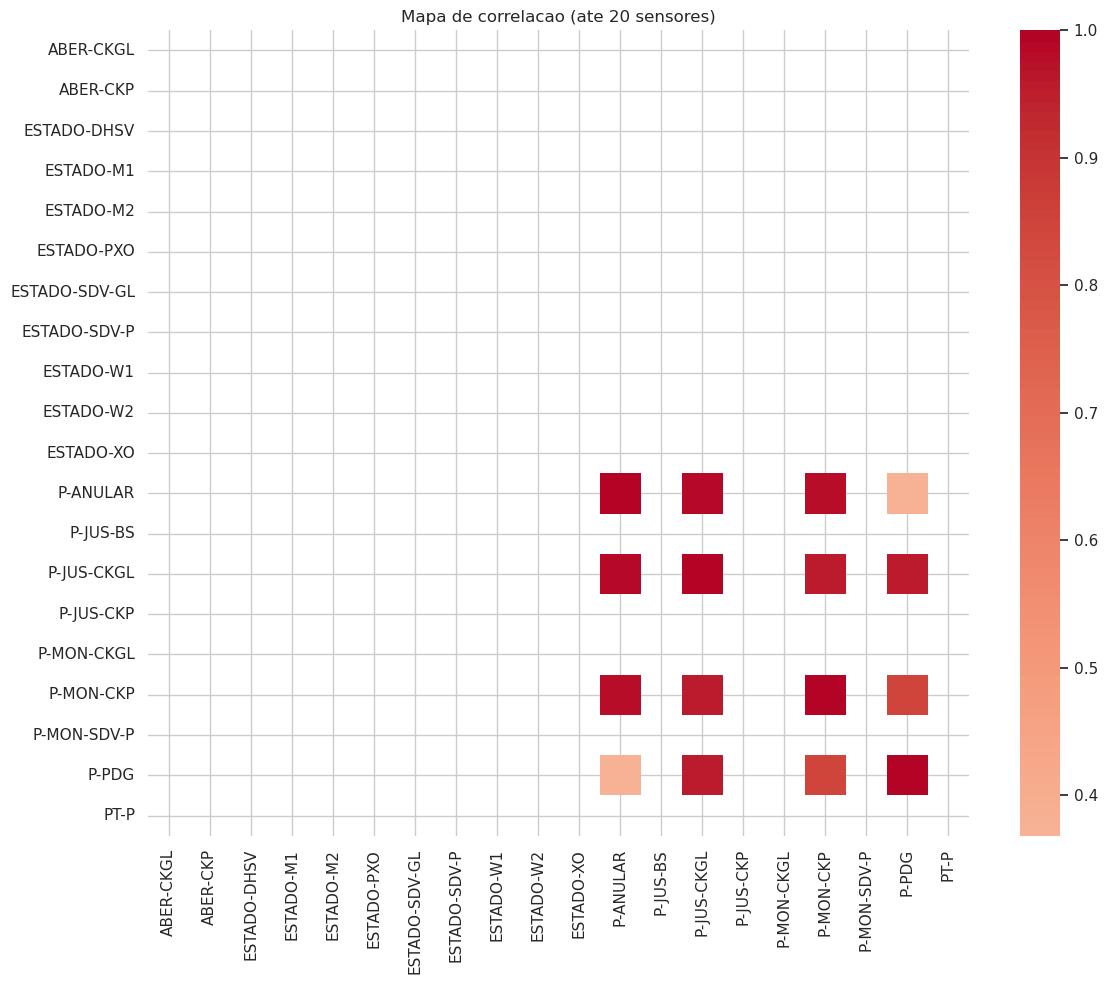

In [10]:
if sensor_cols:
    subset_corr = sensor_cols[:20]
    corr = eda_df[subset_corr].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Mapa de correlacao (ate 20 sensores)')
    plt.tight_layout()
    plt.show()
else:
    print('Sem sensores para matriz de correlacao.')

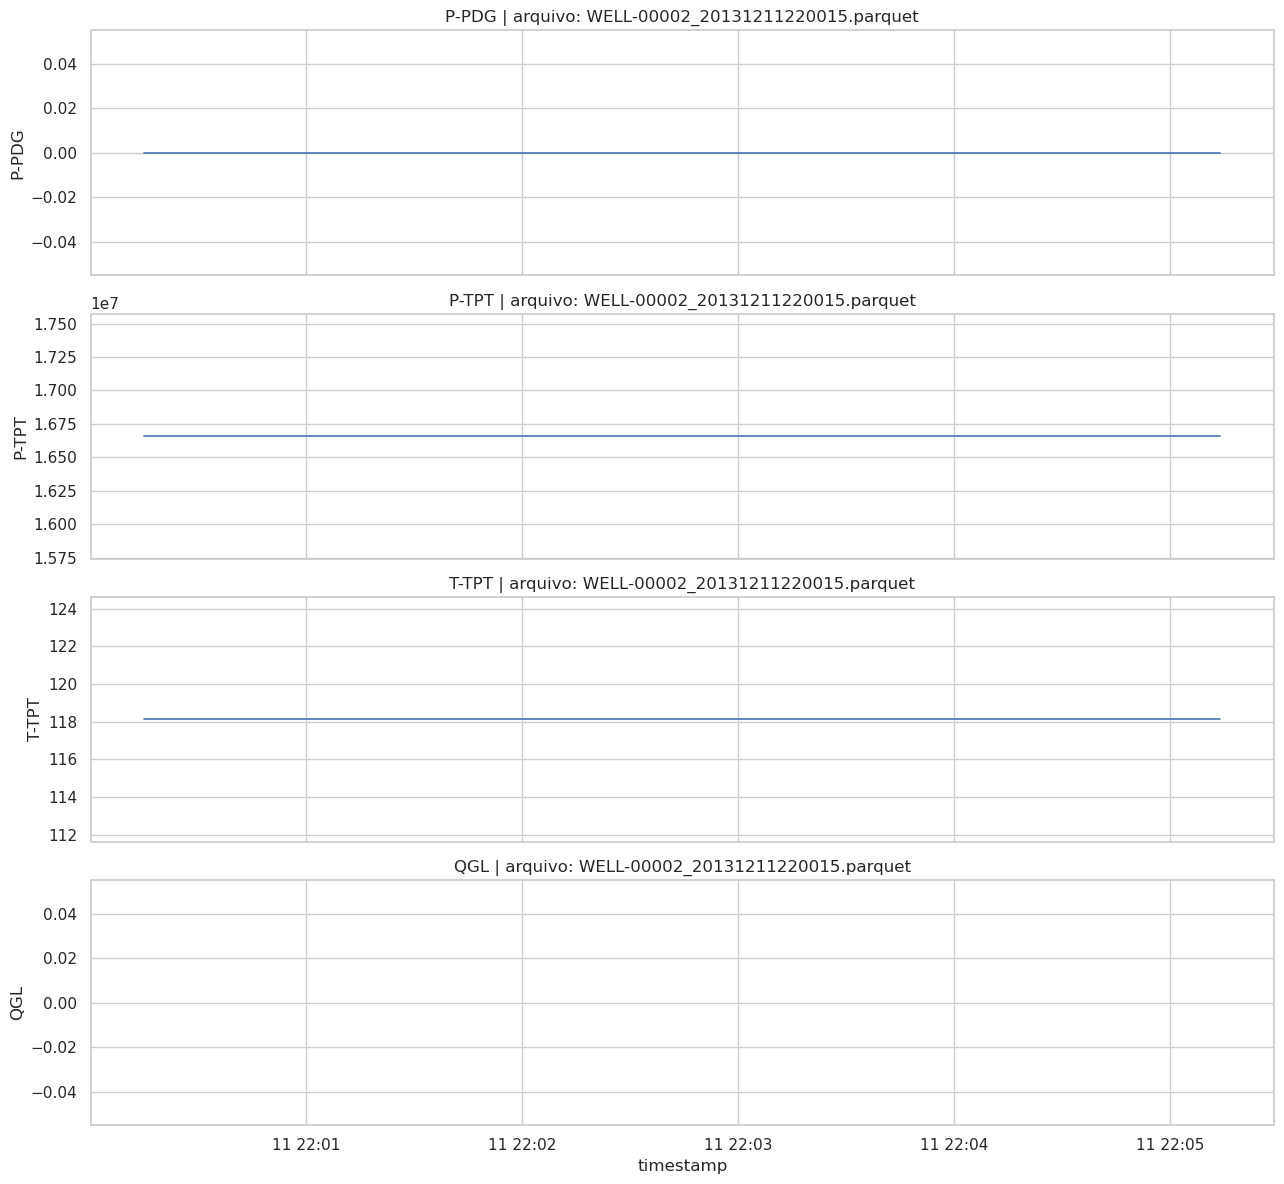

In [11]:
# Serie temporal de exemplo por poco/arquivo
if sensor_cols and eda_df['timestamp'].notna().any():
    plot_cols = [c for c in ['P-PDG', 'P-TPT', 'T-TPT', 'QGL'] if c in sensor_cols]
    if not plot_cols:
        plot_cols = sensor_cols[:3]

    sample_series = (
        eda_df.dropna(subset=['timestamp'])
        .sort_values('timestamp')
        .groupby('source_file')
        .head(300)
    )
    file_escolhido = sample_series['source_file'].iloc[0]
    serie = sample_series[sample_series['source_file'] == file_escolhido]

    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(13, 3 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        ax.plot(serie['timestamp'], serie[col], lw=1.2)
        ax.set_title(f'{col} | arquivo: {file_escolhido}')
        ax.set_ylabel(col)
    axes[-1].set_xlabel('timestamp')
    plt.tight_layout()
    plt.show()
else:
    print('Sem dados suficientes para plot de serie temporal.')

## Proximos passos sugeridos

1. Aumentar `MAX_FILES` e `MAX_ROWS_PER_FILE` para aproximar o comportamento do dataset completo.
2. Separar analise por evento (`class`) e comparar distribuicoes por sensor.
3. Criar regras de validacao de dados (faixas plausiveis, nulos, gaps temporais).
4. Exportar um dataset `silver` com features agregadas para treino de modelos.